In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [36]:
df = pd.read_csv("sisepuede_raw_inputs_latest_LBY_oct_28.csv")
df.head()

,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_gas_ccs,nemomod_entc_scalar_availability_factor_pp_geothermal,nemomod_entc_scalar_availability_factor_pp_hydropower,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,iso_alpha_3
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,LBY
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,LBY
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,LBY
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,LBY
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,LBY


<Axes: title={'center': 'Crude Oil Exports Projection'}, xlabel='Time Period', ylabel='PJ'>

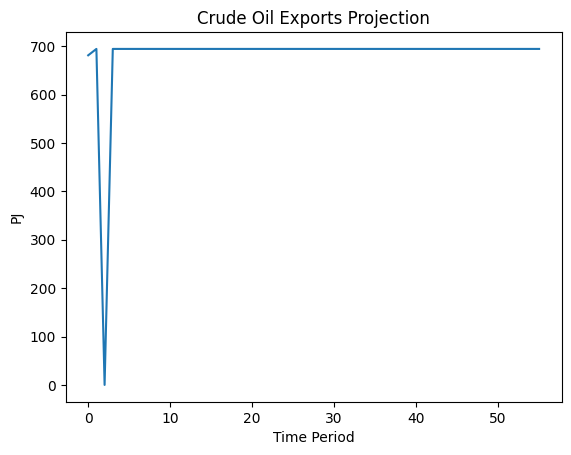

In [37]:
exports_var = "exports_enfu_pj_fuel_crude"
df[exports_var].plot(kind="line", title="Crude Oil Exports Projection", ylabel="PJ", xlabel="Time Period")

<Axes: title={'center': 'Crude Oil Imports Projection'}, xlabel='Time Period', ylabel='Fraction'>

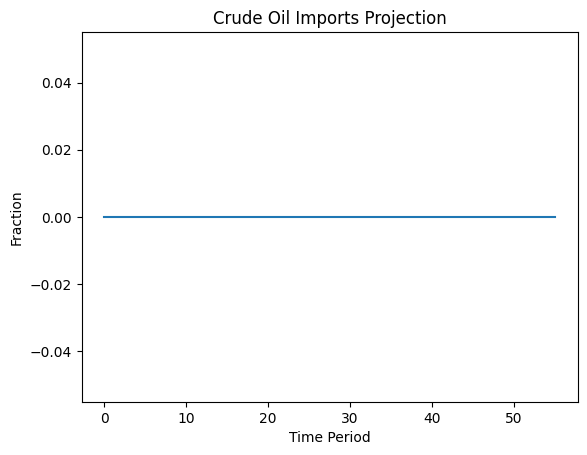

In [38]:
imports_var= "frac_enfu_fuel_demand_imported_pj_fuel_crude"
df[imports_var].plot(kind="line", title="Crude Oil Imports Projection", ylabel="Fraction", xlabel="Time Period")

### Update exports for crude oil

In [40]:
pj_per_day = 919828/170604.21187678
pj_export_total = 365.25*pj_per_day
pj_export_total

1969.2783273290725

<Axes: title={'center': 'Updated Crude Oil Exports Projection'}, xlabel='Time Period', ylabel='PJ'>

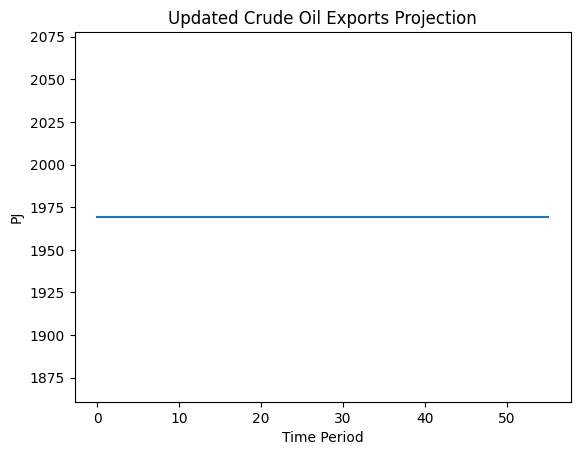

In [41]:
# Update exports for crude oil
df[exports_var] = pj_export_total
df[exports_var].plot(kind="line", title="Updated Crude Oil Exports Projection", ylabel="PJ", xlabel="Time Period")

### Check Exports and imports of petroleum derived products

- Gasoline.
- Oil.
- Hydrocarbon Gas Liquids.
- Kerosene.
- Diesel

In [60]:
petroleum_products = [
    "gasoline",
    "oil",
    "hydrocarbon_gas_liquids",
    "kerosene",
    "diesel"
]

In [49]:
def plot_columns_subplots(df, columns, x_col=None, kind='line', figsize=None,
                          sharex=True, titles=None, ylabels=None, suptitle=None):
    """
    Plot a list of columns (or lists of columns) as stacked subplots.

    - df: DataFrame
    - columns: list where each item is either a column name (str) or a list of column names to plot on the same subplot
    - x_col: column name to use for x axis (if None or missing, df.index is used)
    - kind: 'line' or 'bar' (defaults to 'line')
    - figsize: tuple, default is (10, 3 * n_subplots)
    - sharex: whether subplots share x axis
    - titles: optional list of subplot titles (length must match number of subplots)
    - ylabels: optional list of y labels (length must match number of subplots)
    - suptitle: optional figure title

    Returns: (fig, axes)
    """
    # normalize columns entries to lists
    cols_list = [([c] if isinstance(c, str) else list(c)) for c in columns]
    n = len(cols_list)
    if figsize is None:
        figsize = (10, 3 * n)

    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=figsize, sharex=sharex)
    if n == 1:
        axes = [axes]

    x = df[x_col] if (x_col and x_col in df.columns) else df.index

    for i, (ax, cols) in enumerate(zip(axes, cols_list)):
        plotted = False
        for col in cols:
            if col in df.columns:
                if kind == 'line':
                    ax.plot(x, df[col], label=col)
                elif kind == 'bar':
                    ax.bar(x, df[col], label=col)
                else:
                    ax.plot(x, df[col], label=col)
                plotted = True

        if not plotted:
            ax.text(0.5, 0.5, "No data for these columns",
                    ha="center", va="center", transform=ax.transAxes)

        title = titles[i] if (titles and i < len(titles)) else ", ".join(cols)
        ylabel = ylabels[i] if (ylabels and i < len(ylabels)) else ""
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(True)
        ax.legend()

    xlabel = x_col if (x_col and x_col in df.columns) else "Index"
    axes[-1].set_xlabel(xlabel)

    if suptitle:
        fig.suptitle(suptitle)
        fig.subplots_adjust(top=0.92)

    fig.tight_layout()
    plt.show()
    return fig, axes

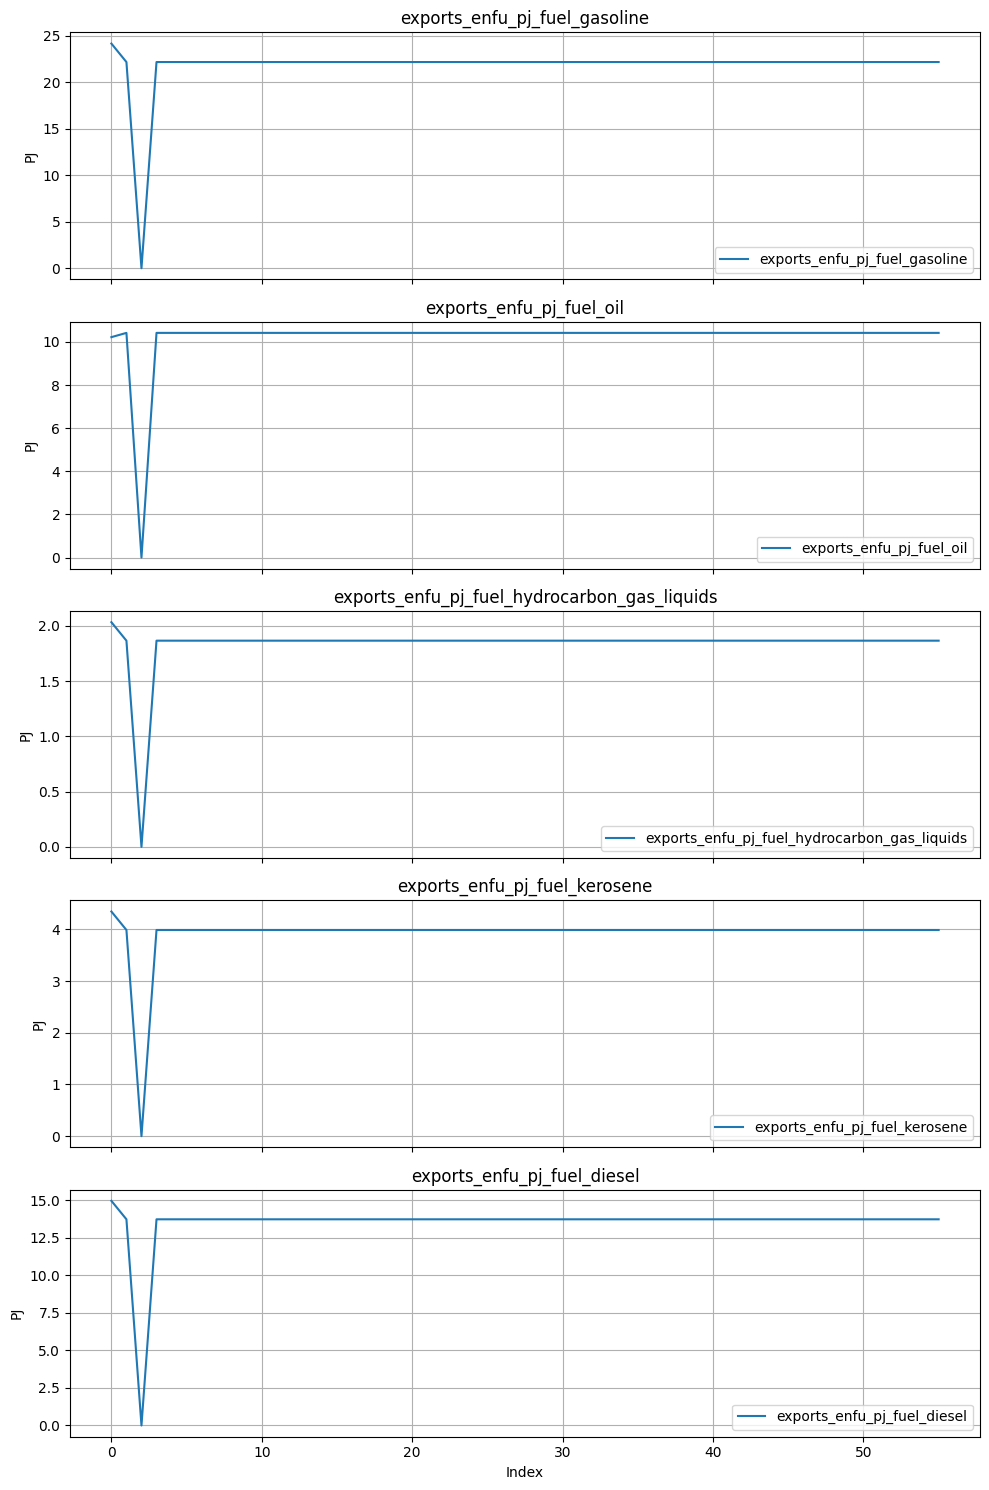

(<Figure size 1000x1500 with 5 Axes>,
 array([<Axes: title={'center': 'exports_enfu_pj_fuel_gasoline'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_oil'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_hydrocarbon_gas_liquids'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_kerosene'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_diesel'}, xlabel='Index', ylabel='PJ'>],
       dtype=object))

In [54]:
plot_columns_subplots(
    df=df,
    columns=[f"exports_enfu_pj_fuel_{prod}" for prod in petroleum_products],
    ylabels=["PJ"] * len(petroleum_products),

)

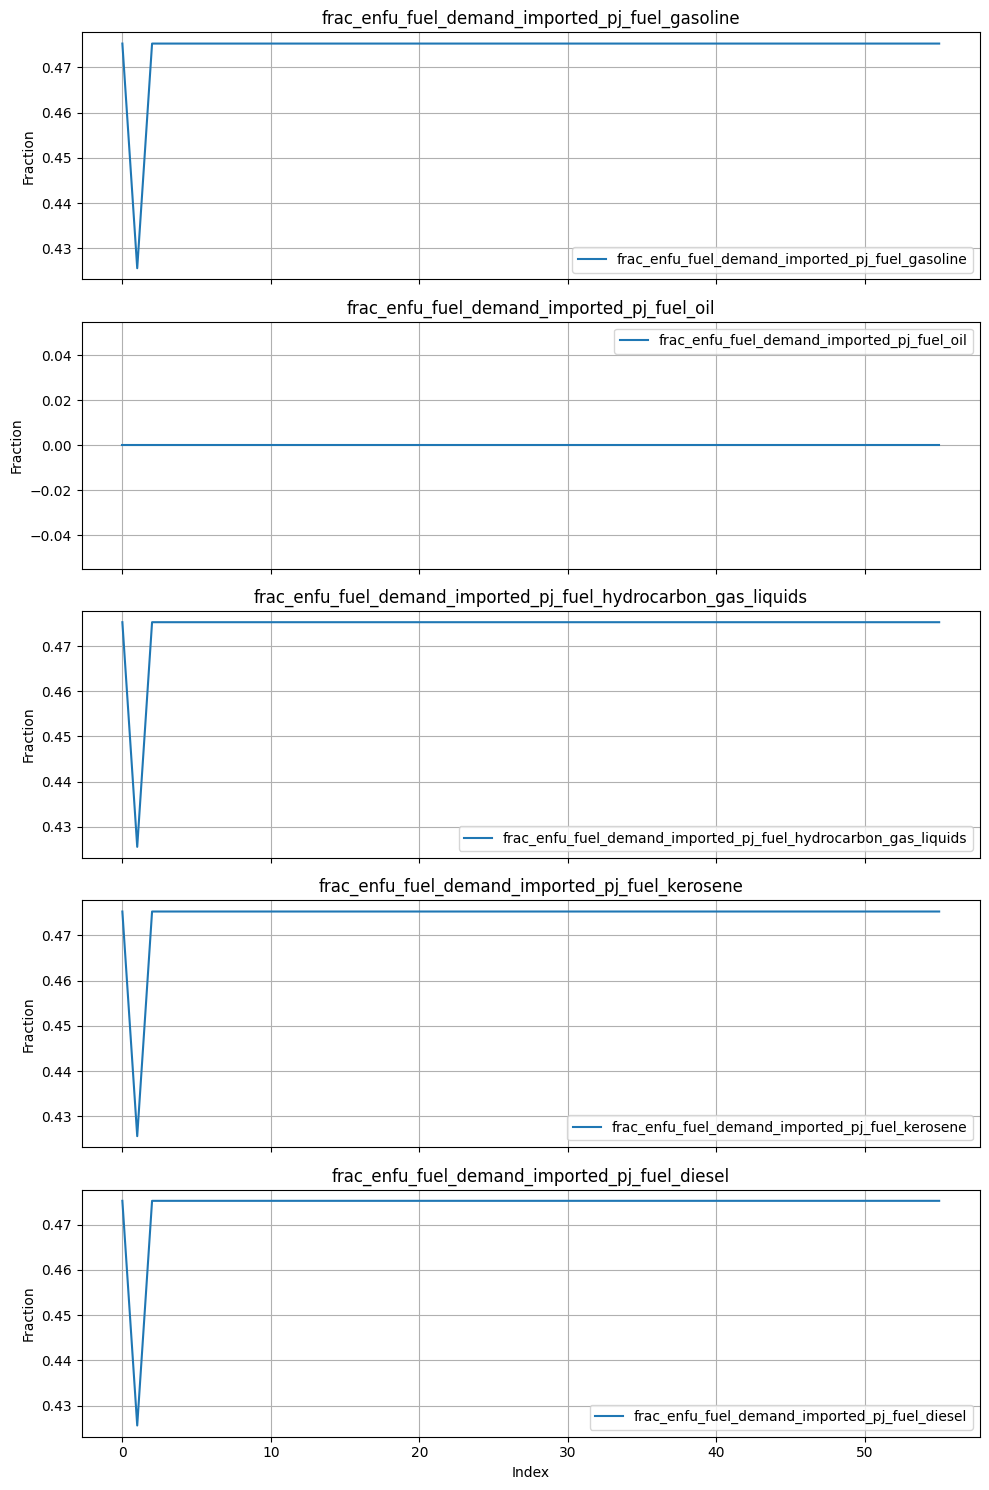

(<Figure size 1000x1500 with 5 Axes>,
 array([<Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_gasoline'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_oil'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_hydrocarbon_gas_liquids'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_kerosene'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_diesel'}, xlabel='Index', ylabel='Fraction'>],
       dtype=object))

In [56]:
plot_columns_subplots(
    df=df,
    columns=[f"frac_enfu_fuel_demand_imported_pj_fuel_{prod}" for prod in petroleum_products],
    ylabels=["Fraction"] * len(petroleum_products),

)

## Update Petroleum Products exports and imports

The following estimates use the **latest available (2023–2024)** public data to quantify:

1. **Total exports of each fuel (PJ)**, and
2. **Fraction of total fuel demand that is imported**.

**Sources and methodology:**

* Export quantities for **propane (HS 271112)** and **butane (HS 271113)** were taken from **UN Comtrade / WITS (2023)**. Libya exported ≈ 401.9 million kg of propane and 14.5 million kg of butane.
* Energy content was converted using **IPCC (2006)** net calorific values (Propane = 46.44 MJ/kg; Butane = 45.75 MJ/kg).
  [
  E_{\text{exports}}(\text{PJ}) = \frac{\text{mass (kg)} \times \text{NCV (MJ/kg)}}{10^9}
  ]
  → Propane ≈ 18.66 PJ, Butane ≈ 0.67 PJ → **Total HGL exports ≈ 19.3 PJ**.
* For gasoline, diesel, kerosene, and fuel oil, open-source trade data show **negligible exports**; Libya is a **net importer** of these products (EIA Country Profile 2023).

**Import fractions:**

* Overall refined-product imports ≈ 10.35 Mt versus national fuel demand ≈ 11 Mt → ≈ 94 % import dependency (Financial Times 2024 via Kpler).
* Product-level import shares used:

  * Gasoline ≈ 0.95 (import-dominated)
  * Diesel ≈ 0.70 (≈ 70 % imported)
  * Kerosene ≈ 0.94 (system average proxy)
  * Fuel oil ≈ 0.94 (proxy)
  * Hydrocarbon Gas Liquids ≈ 0.00 (net exporter)

**References:**
UN Comtrade / WITS 2023 (export volumes by HS code 271112 and 271113); IPCC (2006) Guidelines for NCVs; EIA Libya Country Analysis (2023); Financial Times 2024 citing Kpler trade data.


In [61]:
new_exports_values = {
    "gasoline": 0,
    "oil": 0,
    "hydrocarbon_gas_liquids": 19.33,
    "kerosene": 0,
    "diesel": 0
}

new_import_values = {
    "gasoline": 0.95,
    "oil": 0.94,
    "hydrocarbon_gas_liquids": 0.0,
    "kerosene": 0.94,
    "diesel": 0.74
}

for prod in petroleum_products:
    exports_var = f"exports_enfu_pj_fuel_{prod}"
    imports_var = f"frac_enfu_fuel_demand_imported_pj_fuel_{prod}"
    df[exports_var] = new_exports_values[prod]
    df[imports_var] = new_import_values[prod]

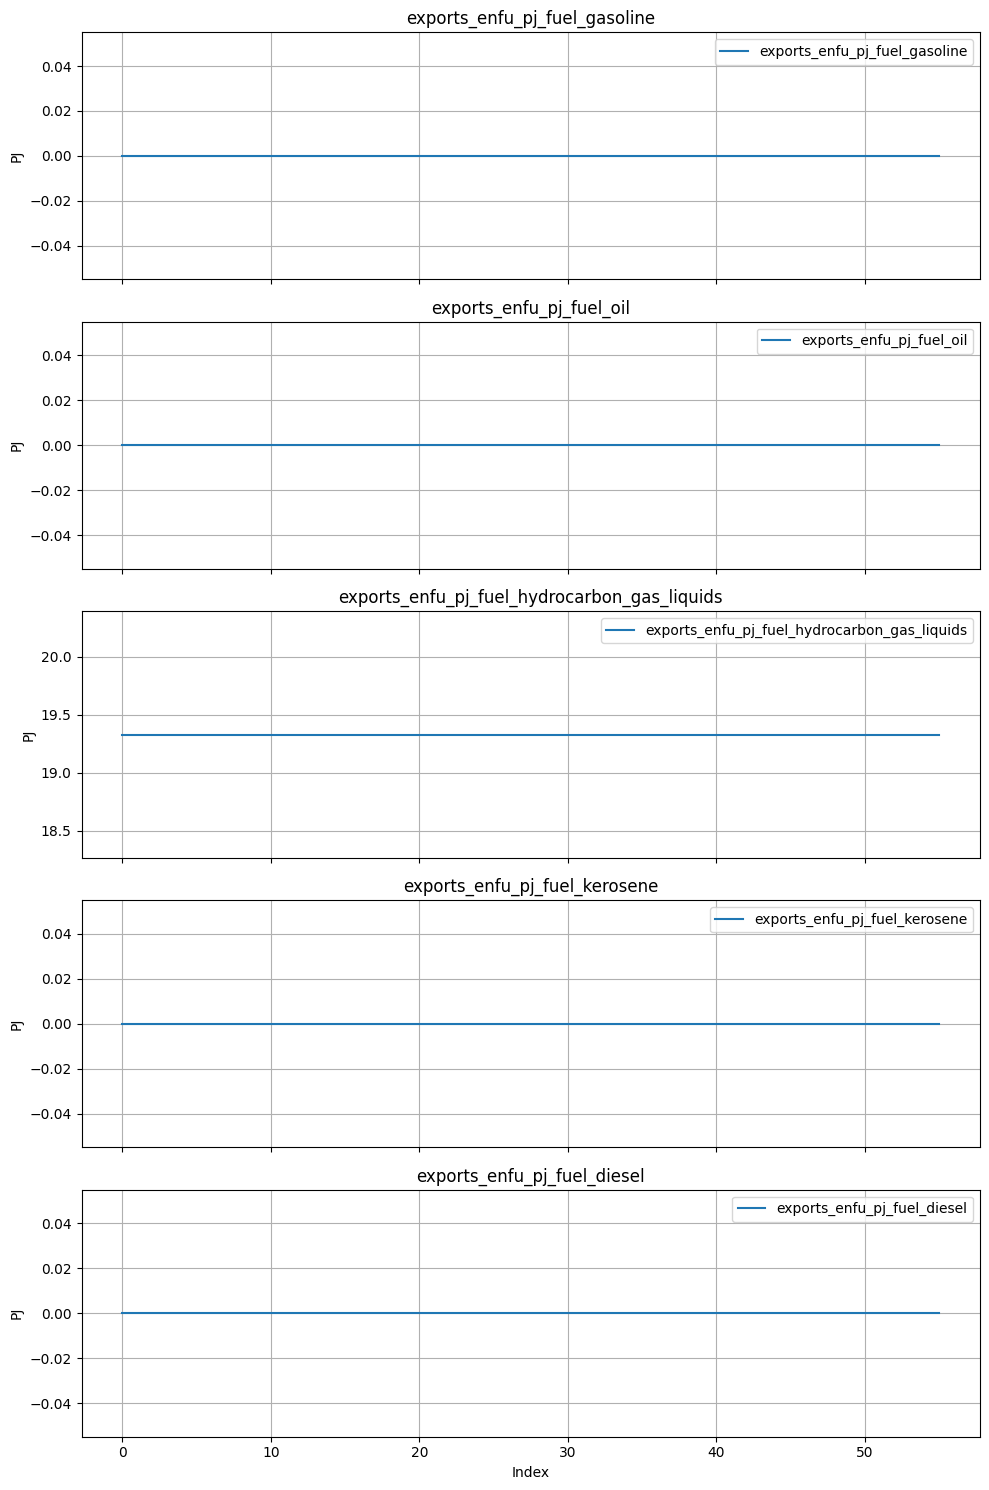

(<Figure size 1000x1500 with 5 Axes>,
 array([<Axes: title={'center': 'exports_enfu_pj_fuel_gasoline'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_oil'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_hydrocarbon_gas_liquids'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_kerosene'}, ylabel='PJ'>,
        <Axes: title={'center': 'exports_enfu_pj_fuel_diesel'}, xlabel='Index', ylabel='PJ'>],
       dtype=object))

In [58]:
plot_columns_subplots(
    df=df,
    columns=[f"exports_enfu_pj_fuel_{prod}" for prod in petroleum_products],
    ylabels=["PJ"] * len(petroleum_products),

)

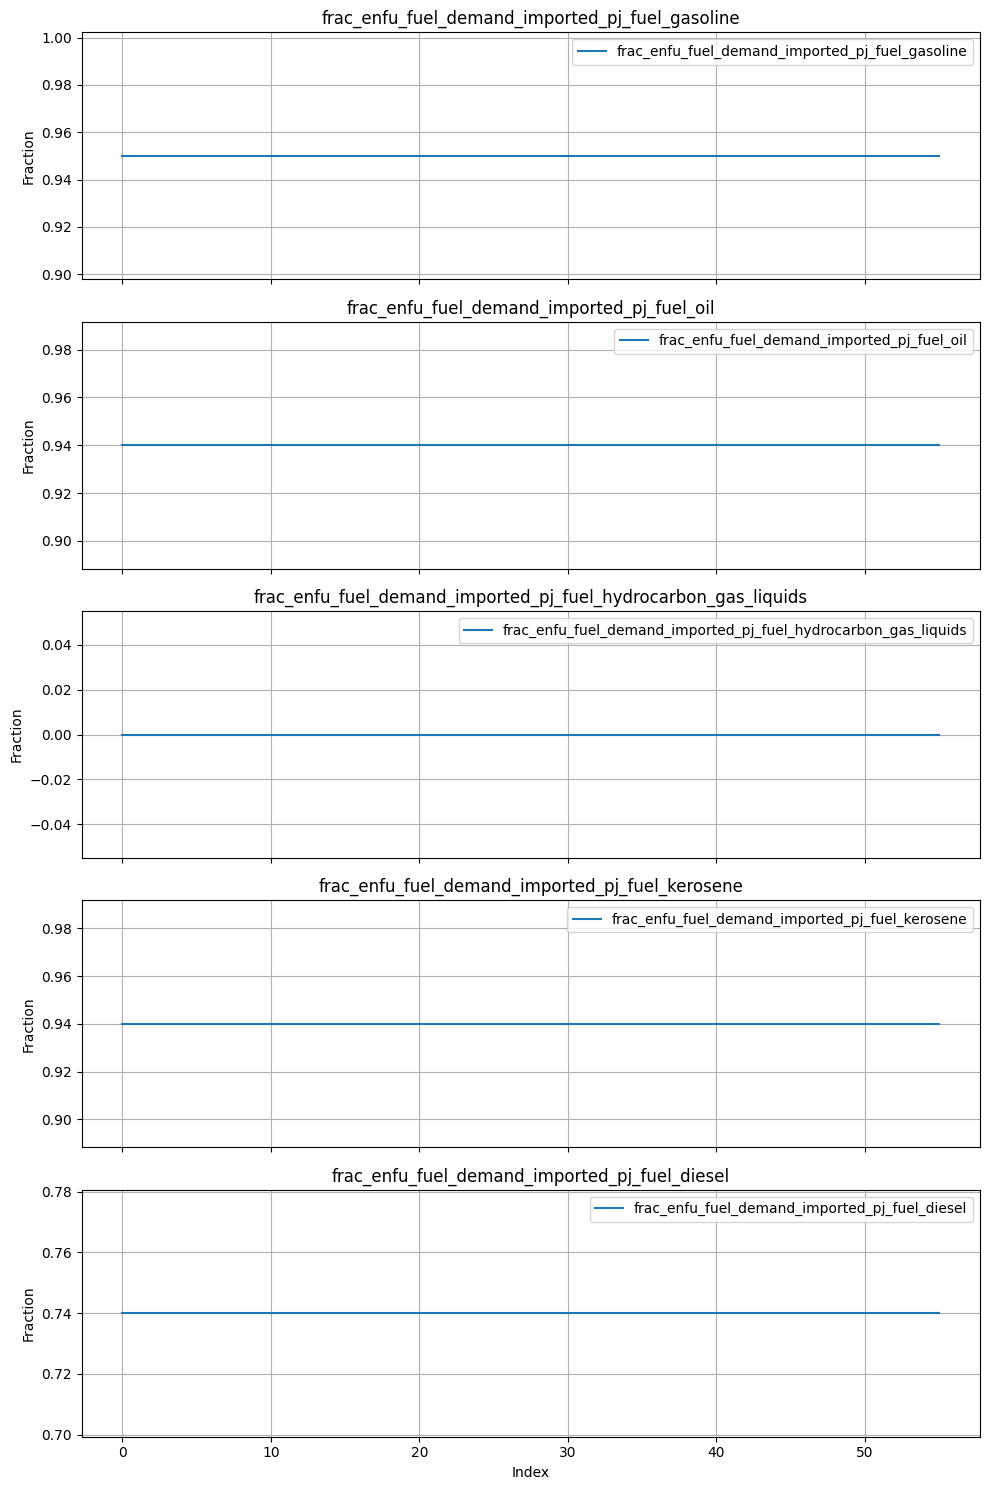

(<Figure size 1000x1500 with 5 Axes>,
 array([<Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_gasoline'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_oil'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_hydrocarbon_gas_liquids'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_kerosene'}, ylabel='Fraction'>,
        <Axes: title={'center': 'frac_enfu_fuel_demand_imported_pj_fuel_diesel'}, xlabel='Index', ylabel='Fraction'>],
       dtype=object))

In [59]:
plot_columns_subplots(
    df=df,
    columns=[f"frac_enfu_fuel_demand_imported_pj_fuel_{prod}" for prod in petroleum_products],
    ylabels=["Fraction"] * len(petroleum_products),

)

### Save updated CSV

In [63]:
df.to_csv("sisepuede_raw_inputs_latest_LBY_oct_28_updated_petroleum.csv", index=False)

# filter to years before and including 2050
df_filtered = df[df['year'] <= 2050]
df_filtered.to_csv("sisepuede_raw_inputs_latest_LBY_oct_28_updated_petroleum_to_2050.csv", index=False)